In [1]:
# ============================================================
# CELL 0: SETUP (Google Colab)
# ============================================================
!pip install -q openpyxl
!pip install -q unsloth

import torch
import random
import numpy as np

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Seed: {SEED}")
print("Ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 186.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ============================================================
# CELL 1: CONFIG (Google Colab paths)
# ============================================================

CONFIG = {
    # Data (Google Drive paths)
    "data_path": "/content/drive/MyDrive/Finetuning/Data.xlsx",
    "output_dir": "/content/drive/MyDrive/Finetuning/output",

    # Split settings
    "seed": 42,

    # Training
    "epochs": 3,
    "batch_size": 4,
    "gradient_accumulation_steps": 4,  # Effective batch = 16
    "learning_rate": 5e-6,
    "weight_decay": 0.01,
    "max_seq_length": 2048,

    # LoRA
    "lora_r": 80,
    "lora_alpha": 80,
    "lora_dropout": 0,
}

import os
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Config loaded!")
print(f"  Data: {CONFIG['data_path']}")
print(f"  Output: {CONFIG['output_dir']}")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Effective batch: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']}")

Config loaded!
  Data: /content/drive/MyDrive/Finetuning/Data.xlsx
  Output: /content/drive/MyDrive/Finetuning/output
  Learning rate: 5e-06
  Effective batch: 16


In [3]:
# ============================================================
# CELL 2: LOAD DATA (Optimized Stratified Split)
# ============================================================
import pandas as pd
import numpy as np
import re
import json

df = pd.read_excel(CONFIG["data_path"])
print(f"Loaded: {len(df)} records")

# Extract question number
df['Q_num'] = df['ID'].apply(lambda x: int(str(x).split(' ')[0].replace('Q', '')))

# Optimized Stratified Split (Balanced by question difficulty)
train_questions = [1, 2, 3, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 17, 20, 23, 24,
                   27, 28, 29, 30, 33, 35, 36, 38, 40, 41, 43, 44, 46, 47, 49,
                   52, 53, 56, 58, 59, 61, 62, 64, 65, 67, 70, 73, 74, 76, 77,
                   79, 82, 83, 85]

val_questions = [16, 26, 32, 34, 37, 39, 42, 48, 50, 51, 54, 60, 63, 66, 71, 72, 78]

test_questions = [4, 8, 18, 19, 21, 22, 25, 31, 45, 55, 57, 68, 69, 75, 80, 81, 84]

print(f"\nOptimized Stratified Split:")

# Create splits
train_df = df[df['Q_num'].isin(train_questions)].copy()
val_df = df[df['Q_num'].isin(val_questions)].copy()
test_df = df[df['Q_num'].isin(test_questions)].copy()

print(f"\nRecords: Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Loaded: 2550 records

Optimized Stratified Split:

Records: Train: 1530 | Val: 510 | Test: 510


In [4]:
# ============================================================
# CELL 3: PROMPT TEMPLATE + HELPER FUNCTIONS
# ============================================================

def clean_text(text):
    """Clean HTML and special characters from text."""
    if not isinstance(text, str):
        return "" if pd.isna(text) else str(text)
    text = re.sub(r'<br\s*/?>', '\n', text, flags=re.IGNORECASE)
    text = re.sub(r'[\u2022\u00A5]\s*\d*\s*', '- ', text)
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    return "\n".join(lines)

def parse_response(response):
    """Parse both off_topic classification and scores from model response."""
    result = {
        "off_topic": "On-Topic",  # default
        "Off_Topic_Reason": "",
        "Clarity_Score": 0,
        "Terminology_Score": 0,
        "Coverage_Score": 0,
        "Accuracy_Score": 0
    }

    # Parse off_topic category
    off_topic_match = re.search(r'"off_topic"\s*:\s*"([^"]+)"', response)
    if off_topic_match:
        result["off_topic"] = off_topic_match.group(1)

    # Parse reason
    reason_match = re.search(r'"Off_Topic_Reason"\s*:\s*"([^"]+)"', response)
    if reason_match:
        result["Off_Topic_Reason"] = reason_match.group(1)

    # Parse scores
    for key in ["Clarity_Score", "Terminology_Score", "Coverage_Score", "Accuracy_Score"]:
        match = re.search(rf'"?{key}"?\s*:\s*(\d+)', response)
        if match:
            result[key] = int(match.group(1))

    return result

PROMPT = """You are an expert AI Teaching Assistant evaluating student responses for accounting questions.

**QUESTION:** {question}

**MODEL ANSWER (Benchmark):** {model_answer}

**STUDENT ANSWER:** {student_answer}

**STEP 1 - CLASSIFY THE ANSWER:**
First, determine the answer category:
- **On-Topic**: Answer addresses the question asked
- **Off-Topic**: Answer has content but doesn't address the question (wrong topic, irrelevant, or meaningless keywords)
- **No Answer**: Answer is blank or empty

**STEP 2 - PROVIDE REASON:**
Select the EXACT text from this list:
- "Valid answer that addresses the question" (Use only for On-Topic)
- "This is an answer to another question, and doesn't relate to model answer" (Use for Off-Topic irrelevant content)
- "Insufficient answer - may have keywords but without any meaning to the required answer" (Use for Off-Topic meaningless content)
- "No answer provided" (Use for No Answer)

**STEP 3 - IF ON-TOPIC, GRADE USING RUBRIC:**
- **Clarity** (0-2): Answer clarity and directness
- **Terminology** (0-2): Correct business/accounting terms
- **Coverage** (0-2): Addresses main points from model answer
- **Accuracy** (0-4): Factual correctness

**CRITICAL:** If Off-Topic or No Answer, ALL scores must be 0.

**OUTPUT FORMAT:** Respond with ONLY valid JSON:
{{
  "off_topic": "[On-Topic|Off-Topic|No Answer]",
  "Off_Topic_Reason": "[reason]",
  "Clarity_Score": X,
  "Terminology_Score": X,
  "Coverage_Score": X,
  "Accuracy_Score": X
}}"""

print("Prompt template and helper functions ready!")
print("  - clean_text(): Clean HTML and special characters")
print("  - parse_response(): Parse model JSON output")
print("  - PROMPT: 3 categories, 4 reasons, reasoning-first approach")

Prompt template and helper functions ready!
  - clean_text(): Clean HTML and special characters
  - parse_response(): Parse model JSON output
  - PROMPT: 3 categories, 4 reasons, reasoning-first approach


In [5]:
# ============================================================
# CELL 4: CREATE DATASET
# ============================================================

def format_sample(row):
    user_msg = PROMPT.format(
        question=str(row['Question']).strip(),
        model_answer=clean_text(row['Model Answer']),
        student_answer=str(row['Answer Text']).strip()
    )

    # Include off_topic and reason in the output (Reasoning-First approach)
    assistant_msg = json.dumps({
        "off_topic": str(row['off_topic']),
        "Off_Topic_Reason": str(row['Off_Topic_Reason']),
        "Clarity_Score": int(row['Clarity_Score']),
        "Terminology_Score": int(row['Terminology_Score']),
        "Coverage_Score": int(row['Coverage_Score']),
        "Accuracy_Score": int(row['Accuracy_Score'])
    }, indent=2)

    return f"<start_of_turn>user\n{user_msg}<end_of_turn>\n<start_of_turn>model\n{assistant_msg}<end_of_turn>"

# Create datasets
train_data = [{"text": format_sample(row)} for _, row in train_df.iterrows()]
val_data = [{"text": format_sample(row)} for _, row in val_df.iterrows()]
test_data = [{"text": format_sample(row)} for _, row in test_df.iterrows()]

from datasets import Dataset
train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

# Show distribution of off_topic in each split
print(f"\nOff-Topic Distribution:")
print(f"  Train: {train_df['off_topic'].value_counts().to_dict()}")
print(f"  Val:   {val_df['off_topic'].value_counts().to_dict()}")
print(f"  Test:  {test_df['off_topic'].value_counts().to_dict()}")

Train samples: 1530 | Val samples: 510

Off-Topic Distribution:
  Train: {'On-Topic': 1250, 'Off-Topic': 204, 'No Answer': 76}
  Val:   {'On-Topic': 412, 'Off-Topic': 66, 'No Answer': 32}
  Test:  {'On-Topic': 420, 'Off-Topic': 55, 'No Answer': 35}


In [ ]:
# ============================================================
# CELL 5: LOAD MODEL
# ============================================================
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-2-9b-it",
    max_seq_length=CONFIG["max_seq_length"],
    dtype=torch.bfloat16,
    load_in_4bit=False,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=CONFIG["seed"],
)

print("Model loaded with LoRA!")
print(f"  Precision: bfloat16 (full, not 4bit)")
print(f"  LoRA r={CONFIG['lora_r']}, alpha={CONFIG['lora_alpha']}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.1.4: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.32 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

Unsloth 2026.1.4 patched 42 layers with 42 QKV layers, 42 O layers and 42 MLP layers.


Model loaded with LoRA!
  Precision: bfloat16 (full, not 4bit)
  LoRA r=80, alpha=80


In [ ]:
# ============================================================
# CELL 6: TRAIN
# ============================================================
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=CONFIG["max_seq_length"],
    args=TrainingArguments(
        output_dir=CONFIG["output_dir"],
        num_train_epochs=CONFIG["epochs"],
        per_device_train_batch_size=CONFIG["batch_size"],
        per_device_eval_batch_size=CONFIG["batch_size"],
        gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=10,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        load_best_model_at_end=True,
        report_to="none",
        seed=CONFIG["seed"],
        data_seed=CONFIG["seed"],
    ),
)

print("Starting training...")
trainer.train()
print("Training complete!")

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 270,090,240 of 9,511,796,224 (2.84% trained)
Autotune Choices Stats:
{"num_choices": 20, "num_triton_choices": 19, "best_kernel": "triton_bmm_6", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=64, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_warps=4", "best_time": 0.15465599298477173, "best_triton_pos": 0}
AUTOTUNE bmm(64x661x256, 64x256x661)
strides: [s60*s67, s67, 1], [s60*s67, s60, 1]
dtypes: torch.bfloat16, torch.bfloat16
  triton_bmm_6 0.1547 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=64, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_war

Epoch,Training Loss,Validation Loss
1,0.468700,0.477073
2,0.327000,0.471954
3,0.269500,0.488947


Unsloth: Not an error, but Gemma2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Autotune Choices Stats:
{"num_choices": 20, "num_triton_choices": 19, "best_kernel": "triton_bmm_130", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4", "best_time": 0.12355200201272964, "best_triton_pos": 0}
AUTOTUNE bmm(64x627x256, 64x256x627)
strides: [s31*s67, s67, 1], [s31*s67, s31, 1]
dtypes: torch.bfloat16, torch.bfloat16
  triton_bmm_130 0.1236 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4
  triton_bmm_132 0.1252 ms 98.7% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=64, BLOCK_M=128, BLOCK_N=128, EVEN_K=False, GRO

Training complete!


In [ ]:
# ============================================================
# CELL 7: EVALUATE + AUTO-SAVE RESULTS
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix

FastLanguageModel.for_inference(model)

print("=" * 80)
print("EVALUATION (with Off-Topic Detection)")
print("=" * 80)

results = []
detailed_results = []
rubric_diffs = {'Clarity': [], 'Terminology': [], 'Coverage': [], 'Accuracy': []}
rubric_human = {'Clarity': [], 'Terminology': [], 'Coverage': [], 'Accuracy': []}
rubric_llm = {'Clarity': [], 'Terminology': [], 'Coverage': [], 'Accuracy': []}
off_topic_correct = 0
off_topic_total = 0

print(f"{'#':<4} {'Category':<12} {'C':<5} {'T':<5} {'V':<5} {'A':<5} {'Final':<10} {'+-1.0':<7} {'+-0.5'}")
print("=" * 80)

for i, item in enumerate(test_data):
    text = item['text']

    # Get human scores and off_topic
    model_part = text.split('<start_of_turn>model\n')[1].split('<end_of_turn>')[0]
    human = json.loads(model_part)
    h_off = human['off_topic']
    h_reason = human['Off_Topic_Reason']
    h_c, h_t, h_v, h_a = human['Clarity_Score'], human['Terminology_Score'], human['Coverage_Score'], human['Accuracy_Score']

    # Get student ID
    student_id = test_df.iloc[i]['ID']

    # Get model prediction
    prompt = text.split('<start_of_turn>model')[0] + '<start_of_turn>model\n'
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=400, do_sample=False, pad_token_id=tokenizer.pad_token_id)

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    llm = parse_response(response)
    m_off = llm['off_topic']
    m_reason = llm['Off_Topic_Reason']
    m_c, m_t, m_v, m_a = llm['Clarity_Score'], llm['Terminology_Score'], llm['Coverage_Score'], llm['Accuracy_Score']

    # Track off_topic accuracy
    off_topic_total += 1
    if h_off == m_off:
        off_topic_correct += 1

    # Track diffs and scores for QWK
    rubric_diffs['Clarity'].append(abs(h_c - m_c))
    rubric_diffs['Terminology'].append(abs(h_t - m_t))
    rubric_diffs['Coverage'].append(abs(h_v - m_v))
    rubric_diffs['Accuracy'].append(abs(h_a - m_a))

    rubric_human['Clarity'].append(h_c)
    rubric_human['Terminology'].append(h_t)
    rubric_human['Coverage'].append(h_v)
    rubric_human['Accuracy'].append(h_a)

    rubric_llm['Clarity'].append(m_c)
    rubric_llm['Terminology'].append(m_t)
    rubric_llm['Coverage'].append(m_v)
    rubric_llm['Accuracy'].append(m_a)

    human_final = (h_c + h_t + h_v + h_a) / 2
    llm_final = (m_c + m_t + m_v + m_a) / 2
    diff = abs(human_final - llm_final)

    results.append({'human': human_final, 'llm': llm_final})

    # Save detailed results for CSV
    detailed_results.append({
        'student_id': student_id,
        'Human_OffTopic': h_off,
        'LLM_OffTopic': m_off,
        'OffTopic_Match': h_off == m_off,
        'Human_Reason': h_reason,
        'LLM_Reason': m_reason,
        'Human_Clarity': h_c, 'Human_Terminology': h_t, 'Human_Coverage': h_v, 'Human_Accuracy': h_a,
        'Human_Final': human_final,
        'LLM_Clarity': m_c, 'LLM_Terminology': m_t, 'LLM_Coverage': m_v, 'LLM_Accuracy': m_a,
        'LLM_Final': llm_final,
        'Diff': diff, 'Within_1': diff <= 1.0, 'Within_05': diff <= 0.5,
    })

    # Running accuracy
    diffs = np.array([abs(r['human'] - r['llm']) for r in results])
    acc_1 = np.mean(diffs <= 1.0) * 100
    acc_05 = np.mean(diffs <= 0.5) * 100

    status = "Y" if h_off == m_off else "X"
    print(f"{i+1:<4} {h_off[:10]:<12} {h_c}->{m_c:<3} {h_t}->{m_t:<3} {h_v}->{m_v:<3} {h_a}->{m_a:<3} {human_final}->{llm_final:<4} {acc_1:.1f}%   {acc_05:.1f}% {status}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

# Off-Topic Classification
print(f"\nOFF-TOPIC CLASSIFICATION:")
print(f"  Accuracy: {off_topic_correct}/{off_topic_total} ({off_topic_correct/off_topic_total*100:.1f}%)")

results_df = pd.DataFrame(detailed_results)
print(f"\n  Per-Category Accuracy:")
for cat in ['On-Topic', 'Off-Topic', 'No Answer']:
    cat_df = results_df[results_df['Human_OffTopic'] == cat]
    if len(cat_df) > 0:
        cat_acc = cat_df['OffTopic_Match'].mean() * 100
        print(f"    {cat}: {cat_acc:.1f}% ({len(cat_df)} samples)")

# Rubric Scores (MAE)
print(f"\nRUBRIC SCORES (MAE):")
for r, d in rubric_diffs.items():
    print(f"  {r}: {np.mean(d):.2f}")

# Final Grade Metrics
human_grades = np.array([r['human'] for r in results])
llm_grades = np.array([r['llm'] for r in results])
final_diffs = np.abs(human_grades - llm_grades)

print(f"\nFINAL GRADE:")
print(f"  MAE: {np.mean(final_diffs):.2f}")
print(f"  +-0.5 Accuracy: {np.mean(final_diffs <= 0.5)*100:.1f}%")
print(f"  +-1.0 Accuracy: {np.mean(final_diffs <= 1.0)*100:.1f}%")

# ============================================================
# QUADRATIC WEIGHTED KAPPA (QWK)
# ============================================================
print(f"\nQUADRATIC WEIGHTED KAPPA (QWK):")
for rubric in ['Clarity', 'Terminology', 'Coverage', 'Accuracy']:
    qwk = cohen_kappa_score(rubric_human[rubric], rubric_llm[rubric], weights='quadratic')
    print(f"  {rubric}: {qwk:.3f}")

# Overall QWK (using sum of all rubrics as single score)
all_human = [h_c + h_t + h_v + h_a for h_c, h_t, h_v, h_a in
             zip(rubric_human['Clarity'], rubric_human['Terminology'],
                 rubric_human['Coverage'], rubric_human['Accuracy'])]
all_llm = [m_c + m_t + m_v + m_a for m_c, m_t, m_v, m_a in
           zip(rubric_llm['Clarity'], rubric_llm['Terminology'],
               rubric_llm['Coverage'], rubric_llm['Accuracy'])]
overall_qwk = cohen_kappa_score(all_human, all_llm, weights='quadratic')
print(f"  Overall: {overall_qwk:.3f}")

# ============================================================
# CONFUSION MATRIX (Accuracy Rubric 0-4)
# ============================================================
print(f"\nCONFUSION MATRIX (Accuracy Rubric 0-4):")
print("  Rows = Human, Columns = LLM")
cm = confusion_matrix(rubric_human['Accuracy'], rubric_llm['Accuracy'], labels=[0, 1, 2, 3, 4])
print(f"       LLM:  0    1    2    3    4")
for i, row in enumerate(cm):
    print(f"  Human {i}: {row[0]:4d} {row[1]:4d} {row[2]:4d} {row[3]:4d} {row[4]:4d}")

# AUTO-SAVE RESULTS TO CSV
results_df.to_csv(f"{CONFIG['output_dir']}/finetuned_results.csv", index=False)
print(f"\nResults saved to: {CONFIG['output_dir']}/finetuned_results.csv")

EVALUATION (with Off-Topic Detection)
#    Category     C     T     V     A     Final      +-1.0   +-0.5


Autotune Choices Stats:
{"num_choices": 20, "num_triton_choices": 19, "best_kernel": "triton_bmm_166", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8", "best_time": 0.04620800167322159, "best_triton_pos": 0}
AUTOTUNE bmm(16x641x256, 16x256x641)
strides: [s46*s67, s67, 1], [s46*s67, 1, s67]
dtypes: torch.bfloat16, torch.bfloat16
  triton_bmm_166 0.0462 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8
  triton_bmm_162 0.0468 ms 98.8% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=64, BLOCK_N=128, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8
  triton_bmm_157 0.0475 ms 97.4% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=16, BLOCK_M=64, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_w

1    On-Topic     1->2   2->2   2->2   3->3   4.0->4.5  100.0%   100.0% Y
2    On-Topic     1->2   1->2   1->2   3->3   3.0->4.5  50.0%   50.0% Y
3    On-Topic     1->2   1->2   1->2   3->4   3.0->5.0  33.3%   33.3% Y
4    On-Topic     1->1   0->1   1->1   3->2   2.5->2.5  50.0%   50.0% Y
5    On-Topic     2->2   1->2   2->2   3->4   4.0->5.0  60.0%   40.0% Y
6    On-Topic     1->1   1->1   1->1   3->2   3.0->2.5  66.7%   50.0% Y
7    On-Topic     1->2   1->2   2->2   3->4   3.5->5.0  57.1%   42.9% Y
8    On-Topic     2->2   1->2   2->2   3->3   4.0->4.5  62.5%   50.0% Y
9    On-Topic     1->1   1->1   2->1   1->2   2.5->2.5  66.7%   55.6% Y
10   On-Topic     1->1   2->1   2->1   3->2   4.0->2.5  60.0%   50.0% Y
11   On-Topic     1->2   2->2   2->2   3->4   4.0->5.0  63.6%   45.5% Y
12   On-Topic     1->1   1->1   0->1   2->2   2.0->2.5  66.7%   50.0% Y
13   On-Topic     1->2   2->1   2->2   3->3   4.0->4.0  69.2%   53.8% Y
14   On-Topic     1->1   1->1   1->1   2->2   2.5->2.5  71.4% 

In [ ]:
# ============================================================
# CELL 8: SAVE MODEL
# ============================================================

# Save LoRA adapter
model.save_pretrained(f"{CONFIG['output_dir']}/lora_adapter")
tokenizer.save_pretrained(f"{CONFIG['output_dir']}/lora_adapter")
print(f"Model saved to: {CONFIG['output_dir']}/lora_adapter")

In [ ]:
# ============================================================
# CELL 9: ZEROSHOT BASELINE (Test Set - 510 samples)
# ============================================================
from unsloth import FastLanguageModel
import numpy as np
import pandas as pd

print("=" * 80)
print("ZEROSHOT BASELINE EVALUATION (Test Set)")
print("=" * 80)

# Load base model (no LoRA)
print("Loading base model for zeroshot...")
zs_model, zs_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-2-9b-it",
    max_seq_length=CONFIG["max_seq_length"],
    dtype=torch.bfloat16,
    load_in_4bit=False,
)
FastLanguageModel.for_inference(zs_model)
print("Base model loaded!")

zs_results = []
zs_detailed = []
zs_rubric_diffs = {'Clarity': [], 'Terminology': [], 'Coverage': [], 'Accuracy': []}
zs_off_topic_correct = 0
zs_off_topic_total = 0

print(f"\n{'#':<4} {'Category':<12} {'C':<5} {'T':<5} {'V':<5} {'A':<5} {'Final':<10} {'+-1.0':<7} {'+-0.5'}")
print("=" * 80)

for i, item in enumerate(test_data):
    text = item['text']

    # Get human scores and off_topic
    model_part = text.split('<start_of_turn>model\n')[1].split('<end_of_turn>')[0]
    human = json.loads(model_part)
    h_off = human['off_topic']
    h_reason = human['Off_Topic_Reason']
    h_c, h_t, h_v, h_a = human['Clarity_Score'], human['Terminology_Score'], human['Coverage_Score'], human['Accuracy_Score']

    student_id = test_df.iloc[i]['ID']

    # Get model prediction
    prompt = text.split('<start_of_turn>model')[0] + '<start_of_turn>model\n'
    inputs = zs_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(zs_model.device)

    with torch.no_grad():
        outputs = zs_model.generate(**inputs, max_new_tokens=400, do_sample=False, pad_token_id=zs_tokenizer.pad_token_id)

    response = zs_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    llm = parse_response(response)
    m_off = llm['off_topic']
    m_reason = llm['Off_Topic_Reason']
    m_c, m_t, m_v, m_a = llm['Clarity_Score'], llm['Terminology_Score'], llm['Coverage_Score'], llm['Accuracy_Score']

    # Track off_topic accuracy
    zs_off_topic_total += 1
    if h_off == m_off:
        zs_off_topic_correct += 1

    zs_rubric_diffs['Clarity'].append(abs(h_c - m_c))
    zs_rubric_diffs['Terminology'].append(abs(h_t - m_t))
    zs_rubric_diffs['Coverage'].append(abs(h_v - m_v))
    zs_rubric_diffs['Accuracy'].append(abs(h_a - m_a))

    human_final = (h_c + h_t + h_v + h_a) / 2
    llm_final = (m_c + m_t + m_v + m_a) / 2
    diff = abs(human_final - llm_final)

    zs_results.append({'human': human_final, 'llm': llm_final})
    zs_detailed.append({
        'student_id': student_id,
        'Human_OffTopic': h_off,
        'LLM_OffTopic': m_off,
        'OffTopic_Match': h_off == m_off,
        'Human_Reason': h_reason,
        'LLM_Reason': m_reason,
        'Human_Clarity': h_c, 'Human_Terminology': h_t, 'Human_Coverage': h_v, 'Human_Accuracy': h_a,
        'Human_Final': human_final,
        'LLM_Clarity': m_c, 'LLM_Terminology': m_t, 'LLM_Coverage': m_v, 'LLM_Accuracy': m_a,
        'LLM_Final': llm_final,
        'Diff': diff, 'Within_1': diff <= 1.0, 'Within_05': diff <= 0.5,
    })

    diffs = np.array([abs(r['human'] - r['llm']) for r in zs_results])
    acc_1 = np.mean(diffs <= 1.0) * 100
    acc_05 = np.mean(diffs <= 0.5) * 100

    status = "Y" if h_off == m_off else "X"

    print(f"{i+1:<4} {h_off[:10]:<12} {h_c}->{m_c:<3} {h_t}->{m_t:<3} {h_v}->{m_v:<3} {h_a}->{m_a:<3} {human_final}->{llm_final:<4} {acc_1:.1f}%   {acc_05:.1f}% {status}")

# Summary
print("\n" + "=" * 80)
print("ZEROSHOT SUMMARY")
print("=" * 80)

print(f"\nOFF-TOPIC CLASSIFICATION:")
print(f"  Accuracy: {zs_off_topic_correct}/{zs_off_topic_total} ({zs_off_topic_correct/zs_off_topic_total*100:.1f}%)")

# Per-category breakdown
zs_df = pd.DataFrame(zs_detailed)
print(f"\n  Per-Category Accuracy:")
for cat in ['On-Topic', 'Off-Topic', 'No Answer']:
    cat_df = zs_df[zs_df['Human_OffTopic'] == cat]
    if len(cat_df) > 0:
        cat_acc = cat_df['OffTopic_Match'].mean() * 100
        print(f"    {cat}: {cat_acc:.1f}% ({len(cat_df)} samples)")

print(f"\nRUBRIC SCORES (MAE):")
for r, d in zs_rubric_diffs.items():
    print(f"  {r}: {np.mean(d):.2f}")

zs_human = np.array([r['human'] for r in zs_results])
zs_llm = np.array([r['llm'] for r in zs_results])
zs_diffs = np.abs(zs_human - zs_llm)

ZEROSHOT_ACC_1 = np.mean(zs_diffs <= 1.0) * 100
ZEROSHOT_ACC_05 = np.mean(zs_diffs <= 0.5) * 100

print(f"\nFINAL GRADE:")
print(f"  MAE: {np.mean(zs_diffs):.2f}")
print(f"  +-0.5 Accuracy: {ZEROSHOT_ACC_05:.1f}%")
print(f"  +-1.0 Accuracy: {ZEROSHOT_ACC_1:.1f}%")

# Save zeroshot results
zs_df.to_csv(f"{CONFIG['output_dir']}/zeroshot_results.csv", index=False)
print(f"\nZeroshot results saved to: {CONFIG['output_dir']}/zeroshot_results.csv")

# Cleanup to free memory for fine-tuning
del zs_model, zs_tokenizer
torch.cuda.empty_cache()
print("\nBase model unloaded. Ready for fine-tuning!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
ABLATION STUDY - VALIDATION SET EVALUATION
All configs evaluated on VALIDATION set (510 samples)
Test set is NOT used - reserved for final model only

PART 1: LoRA RANK ABLATION (fixed LR=5e-6, dropout=0, 3 epochs)

Training: r8
  LoRA r=8, alpha=8, dropout=0
  LR=5e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/r8
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers 

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,1.631200,1.517822
2,0.778800,0.744753
3,0.679500,0.687099


Unsloth: Not an error, but Gemma2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Autotune Choices Stats:
{"num_choices": 20, "num_triton_choices": 19, "best_kernel": "triton_bmm_130", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4", "best_time": 0.12422399967908859, "best_triton_pos": 0}
AUTOTUNE bmm(64x627x256, 64x256x627)
strides: [s31*s67, s67, 1], [s31*s67, s31, 1]
dtypes: torch.bfloat16, torch.bfloat16
  triton_bmm_130 0.1242 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4
  triton_bmm_132 0.1247 ms 99.6% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=64, BLOCK_M=128, BLOCK_N=128, EVEN_K=False, GRO


  Training time: 7.8 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating:   0%|          | 0/510 [00:00<?, ?sample/s]Autotune Choices Stats:
{"num_choices": 20, "num_triton_choices": 19, "best_kernel": "bmm", "best_time": 0.03046399913728237, "best_triton_pos": 1, "best_triton_time": 0.033984001725912094, "best_triton_kernel": "triton_bmm_157", "best_triton_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=16, BLOCK_M=64, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_warps=4"}
AUTOTUNE bmm(16x542x256, 16x256x542)
strides: [s46*s67, s67, 1], [s46*s67, 1, s67]
dtypes: torch.bfloat16, torch.bfloat16
  bmm 0.0305 ms 100.0% 
  triton_bmm_157 0.0340 ms 89.6% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=16, BLOCK_M=64, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_warps=4
  triton_bmm_166 0.0351 ms 86.9% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, EVEN_K=False, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8
  triton_bmm_162 0.0


  Evaluation time: 26.9 minutes
  Total time: 34.8 minutes (0.58 hours)

  RESULTS TABLE (VAL SET): r8
  | Metric                          | Value       |
  |---------------------------------|-------------|
  | Epochs                          |           3 |
  | Best Epoch                      |         3.0 |
  | Best Eval Loss                  |      0.6871 |
  |---------------------------------|-------------|
  | Accuracy ±1.0                   |       74.1% |
  | Accuracy ±0.5                   |       56.7% |
  | MAE                             |        0.85 |
  | QWK (0-10 scale)                |       0.763 |
  |---------------------------------|-------------|
  | Off-Topic Detection Accuracy    |       87.5% |
  |   - Off-Topic correct           |   83/98     |
  |   - On-Topic correct            |  363/412    |
  |   - False Positive (On→Off)     |          49 |
  |   - False Negative (Off→On)     |          15 |
  |---------------------------------|-------------|
  | Training

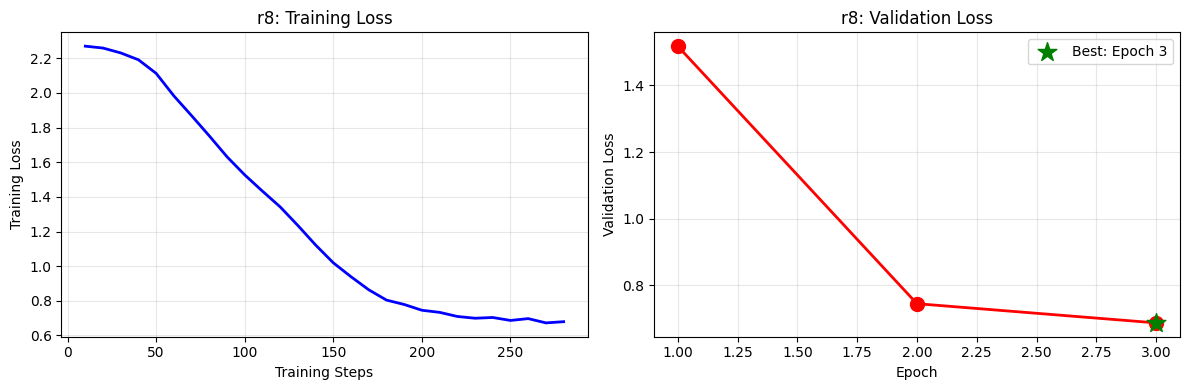

  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r8/best_adapter/

Training: r16
  LoRA r=16, alpha=16, dropout=0
  LR=5e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/r16
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 54,018,048 of 9,295,724,032 (0.58% trained)


Epoch,Training Loss,Validation Loss
1,1.219500,1.002284
2,0.545700,0.538581
3,0.508300,0.525017



  Training time: 7.0 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating: 100%|██████████| 510/510 [30:11<00:00,  3.55s/sample]



  Evaluation time: 30.2 minutes
  Total time: 37.2 minutes (0.62 hours)

  RESULTS TABLE (VAL SET): r16
  | Metric                          | Value       |
  |---------------------------------|-------------|
  | Epochs                          |           3 |
  | Best Epoch                      |         3.0 |
  | Best Eval Loss                  |      0.5250 |
  |---------------------------------|-------------|
  | Accuracy ±1.0                   |       76.7% |
  | Accuracy ±0.5                   |       59.8% |
  | MAE                             |        0.76 |
  | QWK (0-10 scale)                |       0.812 |
  |---------------------------------|-------------|
  | Off-Topic Detection Accuracy    |       91.0% |
  |   - Off-Topic correct           |   78/98     |
  |   - On-Topic correct            |  386/412    |
  |   - False Positive (On→Off)     |          26 |
  |   - False Negative (Off→On)     |          20 |
  |---------------------------------|-------------|
  | Trainin

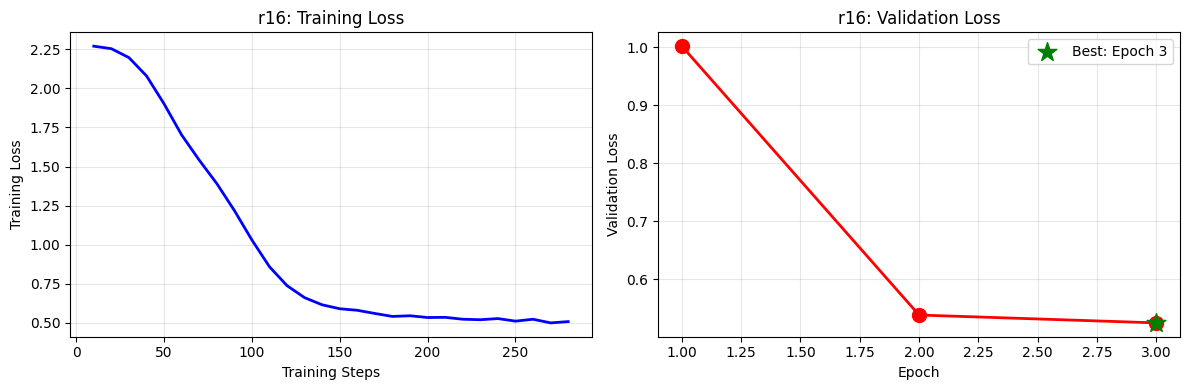

  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r16/best_adapter/

Training: r32
  LoRA r=32, alpha=32, dropout=0
  LR=5e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/r32
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 108,036,096 of 9,349,742,080 (1.16% trained)


Epoch,Training Loss,Validation Loss
1,0.653400,0.572240
2,0.470300,0.485123
3,0.439200,0.479218



  Training time: 7.2 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating: 100%|██████████| 510/510 [30:10<00:00,  3.55s/sample]



  Evaluation time: 30.2 minutes
  Total time: 37.4 minutes (0.62 hours)

  RESULTS TABLE (VAL SET): r32
  | Metric                          | Value       |
  |---------------------------------|-------------|
  | Epochs                          |           3 |
  | Best Epoch                      |         3.0 |
  | Best Eval Loss                  |      0.4792 |
  |---------------------------------|-------------|
  | Accuracy ±1.0                   |       77.1% |
  | Accuracy ±0.5                   |       61.8% |
  | MAE                             |        0.76 |
  | QWK (0-10 scale)                |       0.804 |
  |---------------------------------|-------------|
  | Off-Topic Detection Accuracy    |       91.4% |
  |   - Off-Topic correct           |   78/98     |
  |   - On-Topic correct            |  388/412    |
  |   - False Positive (On→Off)     |          24 |
  |   - False Negative (Off→On)     |          20 |
  |---------------------------------|-------------|
  | Trainin

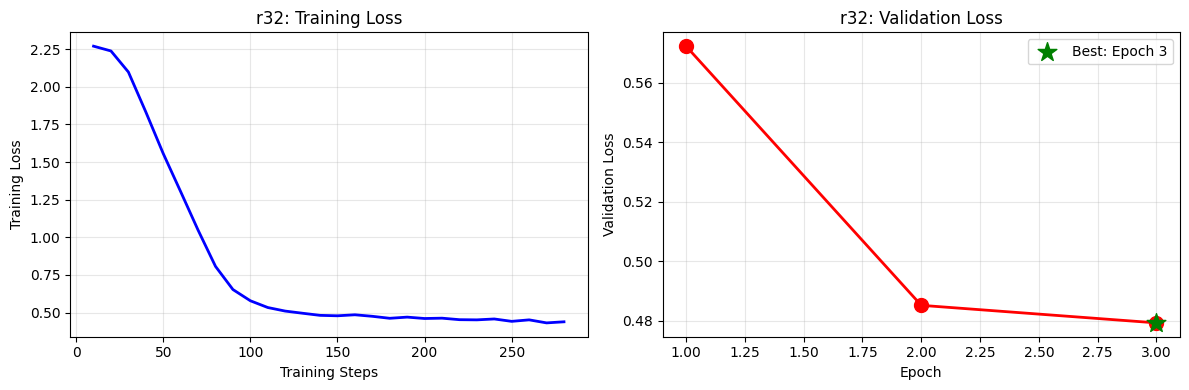

  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r32/best_adapter/

Training: r64
  LoRA r=64, alpha=64, dropout=0
  LR=5e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/r64
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 216,072,192 of 9,457,778,176 (2.28% trained)


Epoch,Training Loss,Validation Loss
1,0.494300,0.490253
2,0.377900,0.462561
3,0.333400,0.466508



  Training time: 7.6 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating: 100%|██████████| 510/510 [30:22<00:00,  3.57s/sample]



  Evaluation time: 30.4 minutes
  Total time: 38.0 minutes (0.63 hours)

  RESULTS TABLE (VAL SET): r64
  | Metric                          | Value       |
  |---------------------------------|-------------|
  | Epochs                          |           3 |
  | Best Epoch                      |         2.0 |
  | Best Eval Loss                  |      0.4626 |
  |---------------------------------|-------------|
  | Accuracy ±1.0                   |       76.9% |
  | Accuracy ±0.5                   |       62.7% |
  | MAE                             |        0.75 |
  | QWK (0-10 scale)                |       0.808 |
  |---------------------------------|-------------|
  | Off-Topic Detection Accuracy    |       91.0% |
  |   - Off-Topic correct           |   73/98     |
  |   - On-Topic correct            |  391/412    |
  |   - False Positive (On→Off)     |          21 |
  |   - False Negative (Off→On)     |          25 |
  |---------------------------------|-------------|
  | Trainin

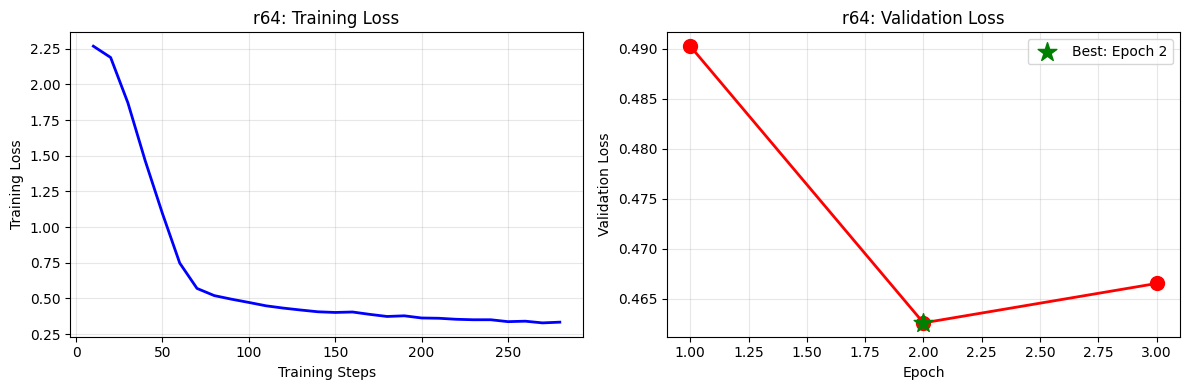

  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r64/best_adapter/

Training: r80
  LoRA r=80, alpha=80, dropout=0
  LR=5e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/r80
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 270,090,240 of 9,511,796,224 (2.84% trained)


Epoch,Training Loss,Validation Loss
1,0.468200,0.476745
2,0.326400,0.471958
3,0.268700,0.488628



  Training time: 8.0 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating: 100%|██████████| 510/510 [30:30<00:00,  3.59s/sample]



  Evaluation time: 30.5 minutes
  Total time: 38.5 minutes (0.64 hours)

  RESULTS TABLE (VAL SET): r80
  | Metric                          | Value       |
  |---------------------------------|-------------|
  | Epochs                          |           3 |
  | Best Epoch                      |         2.0 |
  | Best Eval Loss                  |      0.4720 |
  |---------------------------------|-------------|
  | Accuracy ±1.0                   |       78.4% |
  | Accuracy ±0.5                   |       61.8% |
  | MAE                             |        0.74 |
  | QWK (0-10 scale)                |       0.814 |
  |---------------------------------|-------------|
  | Off-Topic Detection Accuracy    |       91.0% |
  |   - Off-Topic correct           |   74/98     |
  |   - On-Topic correct            |  390/412    |
  |   - False Positive (On→Off)     |          22 |
  |   - False Negative (Off→On)     |          24 |
  |---------------------------------|-------------|
  | Trainin

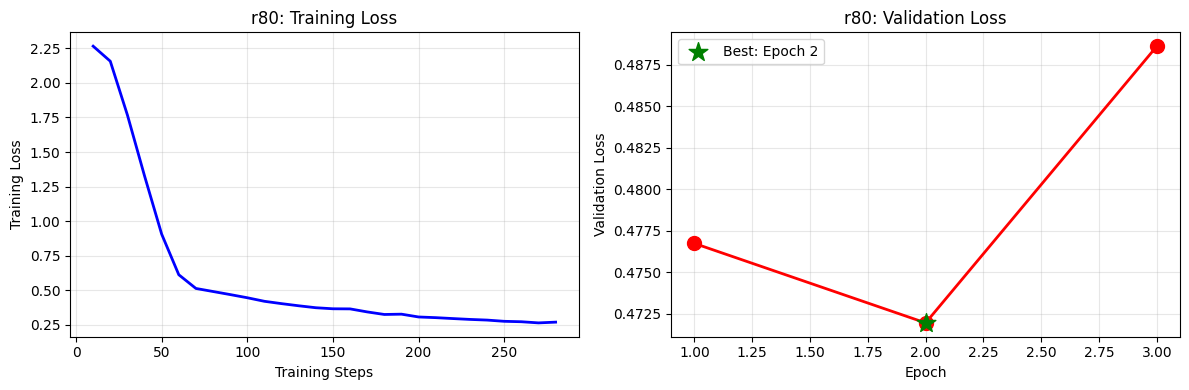

  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r80/best_adapter/

Training: r96
  LoRA r=96, alpha=96, dropout=0
  LR=5e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/r96
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 324,108,288 of 9,565,814,272 (3.39% trained)


Epoch,Training Loss,Validation Loss
1,0.445900,0.468035
2,0.272200,0.495143
3,0.209100,0.528636



  Training time: 8.6 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating: 100%|██████████| 510/510 [30:06<00:00,  3.54s/sample]



  Evaluation time: 30.1 minutes
  Total time: 38.7 minutes (0.65 hours)

  RESULTS TABLE (VAL SET): r96
  | Metric                          | Value       |
  |---------------------------------|-------------|
  | Epochs                          |           3 |
  | Best Epoch                      |         1.0 |
  | Best Eval Loss                  |      0.4680 |
  |---------------------------------|-------------|
  | Accuracy ±1.0                   |       76.5% |
  | Accuracy ±0.5                   |       60.4% |
  | MAE                             |        0.77 |
  | QWK (0-10 scale)                |       0.805 |
  |---------------------------------|-------------|
  | Off-Topic Detection Accuracy    |       91.6% |
  |   - Off-Topic correct           |   79/98     |
  |   - On-Topic correct            |  388/412    |
  |   - False Positive (On→Off)     |          24 |
  |   - False Negative (Off→On)     |          19 |
  |---------------------------------|-------------|
  | Trainin

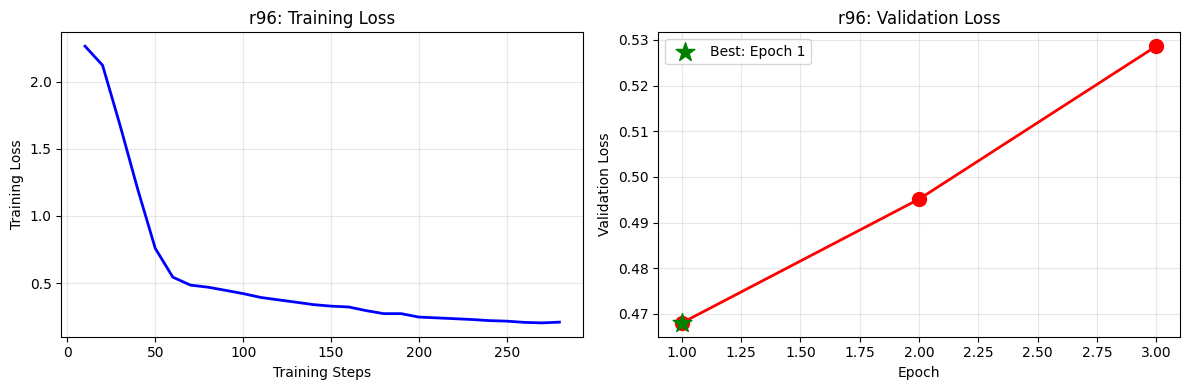

  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r96/best_adapter/

Training: r128
  LoRA r=128, alpha=128, dropout=0
  LR=5e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/r128
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 432,144,384 of 9,673,850,368 (4.47% trained)


Epoch,Training Loss,Validation Loss
1,0.405100,0.460980
2,0.182000,0.569789
3,0.148400,0.609871



  Training time: 8.8 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating: 100%|██████████| 510/510 [30:40<00:00,  3.61s/sample]



  Evaluation time: 30.7 minutes
  Total time: 39.5 minutes (0.66 hours)

  RESULTS TABLE (VAL SET): r128
  | Metric                          | Value       |
  |---------------------------------|-------------|
  | Epochs                          |           3 |
  | Best Epoch                      |         1.0 |
  | Best Eval Loss                  |      0.4610 |
  |---------------------------------|-------------|
  | Accuracy ±1.0                   |       78.0% |
  | Accuracy ±0.5                   |       58.0% |
  | MAE                             |        0.75 |
  | QWK (0-10 scale)                |       0.816 |
  |---------------------------------|-------------|
  | Off-Topic Detection Accuracy    |       90.6% |
  |   - Off-Topic correct           |   74/98     |
  |   - On-Topic correct            |  388/412    |
  |   - False Positive (On→Off)     |          24 |
  |   - False Negative (Off→On)     |          24 |
  |---------------------------------|-------------|
  | Traini

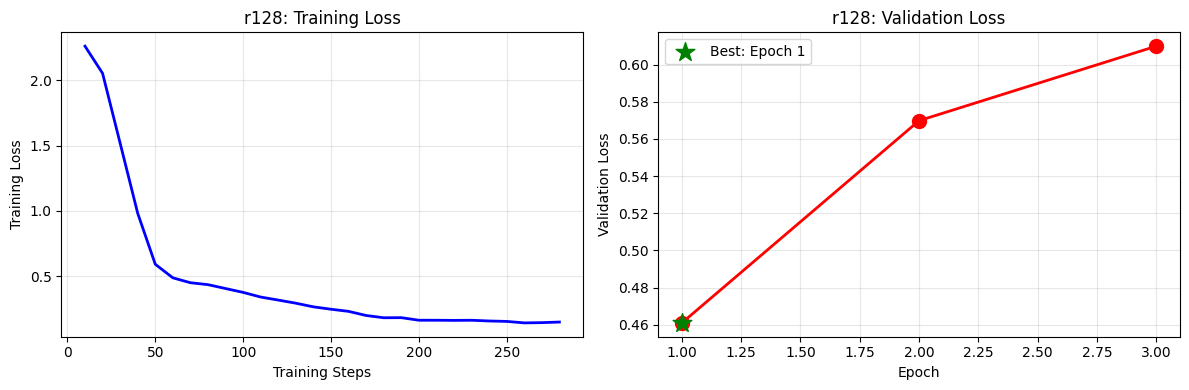

  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r128/best_adapter/

LoRA summary saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/summary_lora_rank.csv

PART 2: LEARNING RATE ABLATION (fixed r=80, dropout=0, 3 epochs)

Training: lr1e-06
  LoRA r=80, alpha=80, dropout=0
  LR=1e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/lr1e-06
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslotha

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/1530 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/510 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 270,090,240 of 9,511,796,224 (2.84% trained)


Epoch,Training Loss,Validation Loss
1,1.525100,1.399775
2,0.721200,0.698026
3,0.627600,0.642925



  Training time: 8.0 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating:   1%|          | 5/510 [00:18<31:34,  3.75s/sample]

In [ ]:
# ============================================================
# CELL 10: ABLATION STUDY - VALIDATION SET EVALUATION
# ============================================================
# Same 13 configs as Cell 10, but evaluated on VALIDATION set (510 samples)
# Results saved to output/ablation_val/ (separate from test-set results)
#
# Part 1: LoRA Rank (r = 8, 16, 32, 64, 80, 96, 128) with fixed LR=5e-6
# Part 2: Learning Rate (1e-6, 5e-6, 1e-5, 2e-5) with fixed r=80
# Part 3: Extended Training (r=32 with 5 epochs)
# Part 4: Dropout Test (r=80, dropout=0.1)

from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from sklearn.metrics import cohen_kappa_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import json
import os
import time
from tqdm import tqdm

# Create ablation_val directory
ABLATION_VAL_DIR = f"{CONFIG['output_dir']}/ablation_val"
os.makedirs(ABLATION_VAL_DIR, exist_ok=True)

def plot_single_config_val(config_name, loss_curve, config_dir):
    """Plot loss curves for a single config immediately after training."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax1 = axes[0]
    ax1.plot(loss_curve['train_steps'], loss_curve['train_losses'], 'b-', linewidth=2)
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Training Loss')
    ax1.set_title(f'{config_name}: Training Loss')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(loss_curve['eval_epochs'], loss_curve['eval_losses'], 'r-o', linewidth=2, markersize=10)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Loss')
    ax2.set_title(f'{config_name}: Validation Loss')
    ax2.grid(True, alpha=0.3)

    best_idx = loss_curve['eval_losses'].index(min(loss_curve['eval_losses']))
    best_epoch = loss_curve['eval_epochs'][best_idx]
    best_loss = loss_curve['eval_losses'][best_idx]
    ax2.scatter([best_epoch], [best_loss], color='green', s=200, zorder=5, marker='*', label=f'Best: Epoch {best_epoch:.0f}')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{config_dir}/loss_curve.png", dpi=100)
    plt.show()

def save_loss_curve_val(config_dir, loss_curve):
    """Save loss curve data to CSV."""
    train_df = pd.DataFrame({
        'step': loss_curve['train_steps'],
        'train_loss': loss_curve['train_losses']
    })
    train_df.to_csv(f"{config_dir}/train_loss.csv", index=False)

    eval_df = pd.DataFrame({
        'epoch': loss_curve['eval_epochs'],
        'eval_loss': loss_curve['eval_losses']
    })
    eval_df.to_csv(f"{config_dir}/eval_loss.csv", index=False)

def print_results_table_val(config_name, metrics):
    """Print a formatted results table after validation evaluation."""
    print(f"\n  {'='*50}")
    print(f"  RESULTS TABLE (VAL SET): {config_name}")
    print(f"  {'='*50}")
    print(f"  | Metric                          | Value       |")
    print(f"  |{'-'*33}|{'-'*13}|")
    print(f"  | Epochs                          | {metrics['epochs']:>11} |")
    print(f"  | Best Epoch                      | {metrics['best_epoch']:>11} |")
    print(f"  | Best Eval Loss                  | {metrics['best_eval_loss']:>11.4f} |")
    print(f"  |{'-'*33}|{'-'*13}|")
    print(f"  | Accuracy ±1.0                   | {metrics['acc_1']:>10.1f}% |")
    print(f"  | Accuracy ±0.5                   | {metrics['acc_05']:>10.1f}% |")
    print(f"  | MAE                             | {metrics['mae']:>11.2f} |")
    print(f"  | QWK (0-10 scale)                | {metrics['qwk']:>11.3f} |")
    print(f"  |{'-'*33}|{'-'*13}|")
    print(f"  | Off-Topic Detection Accuracy    | {metrics['off_topic_acc']:>10.1f}% |")
    print(f"  |   - Off-Topic correct           | {metrics['off_topic_correct']:>4}/{metrics['off_topic_total']:<6} |")
    print(f"  |   - On-Topic correct            | {metrics['on_topic_correct']:>4}/{metrics['on_topic_total']:<6} |")
    print(f"  |   - False Positive (On→Off)     | {metrics['false_positive']:>11} |")
    print(f"  |   - False Negative (Off→On)     | {metrics['false_negative']:>11} |")
    print(f"  |{'-'*33}|{'-'*13}|")
    print(f"  | Training Time                   | {metrics['train_time_min']:>8.1f} min |")
    print(f"  | Evaluation Time                 | {metrics['eval_time_min']:>8.1f} min |")
    print(f"  | Total Time                      | {metrics['total_time_min']:>8.1f} min |")
    print(f"  {'='*50}")

def run_ablation_config_val(config_name, lora_r, lora_alpha, learning_rate, lora_dropout=0, num_epochs=None):
    """Train and evaluate a single ablation configuration on VALIDATION set."""
    epochs = num_epochs if num_epochs else CONFIG["epochs"]

    # Create config folder
    config_dir = f"{ABLATION_VAL_DIR}/{config_name}"
    os.makedirs(config_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Training: {config_name}")
    print(f"  LoRA r={lora_r}, alpha={lora_alpha}, dropout={lora_dropout}")
    print(f"  LR={learning_rate}, Epochs={epochs}")
    print(f"  Evaluating on: VALIDATION SET (510 samples)")
    print(f"  Output folder: {config_dir}")
    print(f"{'='*60}")

    # Load fresh model
    abl_model, abl_tokenizer = FastLanguageModel.from_pretrained(
        model_name="unsloth/gemma-2-9b-it",
        max_seq_length=CONFIG["max_seq_length"],
        dtype=torch.bfloat16,
        load_in_4bit=False,
    )

    abl_model = FastLanguageModel.get_peft_model(
        abl_model,
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=CONFIG["seed"],
    )

    checkpoint_dir = f"{config_dir}/checkpoints"

    trainer = SFTTrainer(
        model=abl_model,
        tokenizer=abl_tokenizer,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        dataset_text_field="text",
        max_seq_length=CONFIG["max_seq_length"],
        args=TrainingArguments(
            output_dir=checkpoint_dir,
            num_train_epochs=epochs,
            per_device_train_batch_size=CONFIG["batch_size"],
            per_device_eval_batch_size=CONFIG["batch_size"],
            gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
            learning_rate=learning_rate,
            weight_decay=CONFIG["weight_decay"],
            lr_scheduler_type="cosine",
            warmup_ratio=0.1,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            logging_steps=10,
            fp16=not torch.cuda.is_bf16_supported(),
            bf16=torch.cuda.is_bf16_supported(),
            report_to="none",
            seed=CONFIG["seed"],
        ),
    )

    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    print(f"\n  Training time: {train_time/60:.1f} minutes")

    # Extract loss curves
    train_losses, train_steps, eval_losses, eval_epochs = [], [], [], []
    for log in trainer.state.log_history:
        if 'loss' in log and 'eval_loss' not in log:
            train_losses.append(log['loss'])
            train_steps.append(log['step'])
        if 'eval_loss' in log:
            eval_losses.append(log['eval_loss'])
            eval_epochs.append(log['epoch'])

    loss_curve = {
        'train_steps': train_steps,
        'train_losses': train_losses,
        'eval_epochs': eval_epochs,
        'eval_losses': eval_losses
    }

    # Save loss curves
    save_loss_curve_val(config_dir, loss_curve)

    best_epoch = eval_epochs[eval_losses.index(min(eval_losses))] if eval_losses else epochs
    best_eval_loss = min(eval_losses) if eval_losses else 0

    # ============================================================
    # EVALUATE ON VALIDATION SET (key difference from Cell 10)
    # ============================================================
    FastLanguageModel.for_inference(abl_model)

    abl_results = []
    human_totals = []
    llm_totals = []
    detailed_results = []

    off_topic_total = 0
    off_topic_correct = 0
    on_topic_total = 0
    on_topic_correct = 0
    false_positive = 0
    false_negative = 0

    eval_start = time.time()
    print(f"\n  Evaluating on VALIDATION set ({len(val_data)} samples)...")
    for i, item in enumerate(tqdm(val_data, desc="  Validating", unit="sample")):
        text = item['text']
        model_part = text.split('<start_of_turn>model\n')[1].split('<end_of_turn>')[0]
        human = json.loads(model_part)
        h_off = human['off_topic']
        h_reason = human['Off_Topic_Reason']
        h_c, h_t, h_v, h_a = human['Clarity_Score'], human['Terminology_Score'], human['Coverage_Score'], human['Accuracy_Score']

        student_id = val_df.iloc[i]['ID']

        prompt = text.split('<start_of_turn>model')[0] + '<start_of_turn>model\n'
        inputs = abl_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(abl_model.device)

        with torch.no_grad():
            outputs = abl_model.generate(**inputs, max_new_tokens=400, do_sample=False, pad_token_id=abl_tokenizer.pad_token_id)

        response = abl_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        llm = parse_response(response)
        m_off = llm['off_topic']
        m_reason = llm['Off_Topic_Reason']
        m_c, m_t, m_v, m_a = llm['Clarity_Score'], llm['Terminology_Score'], llm['Coverage_Score'], llm['Accuracy_Score']

        if h_off in ['Off-Topic', 'No Answer']:
            off_topic_total += 1
            if m_off in ['Off-Topic', 'No Answer']:
                off_topic_correct += 1
            else:
                false_negative += 1
        else:
            on_topic_total += 1
            if m_off == 'On-Topic':
                on_topic_correct += 1
            else:
                false_positive += 1

        human_final = (h_c + h_t + h_v + h_a) / 2
        llm_final = (m_c + m_t + m_v + m_a) / 2
        diff = abs(human_final - llm_final)

        abl_results.append({'human': human_final, 'llm': llm_final})
        human_totals.append(h_c + h_t + h_v + h_a)
        llm_totals.append(m_c + m_t + m_v + m_a)

        detailed_results.append({
            'student_id': student_id,
            'Human_OffTopic': h_off,
            'LLM_OffTopic': m_off,
            'OffTopic_Match': h_off == m_off,
            'Human_Reason': h_reason,
            'LLM_Reason': m_reason,
            'Human_Clarity': h_c,
            'LLM_Clarity': m_c,
            'Clarity_Diff': abs(h_c - m_c),
            'Human_Terminology': h_t,
            'LLM_Terminology': m_t,
            'Terminology_Diff': abs(h_t - m_t),
            'Human_Coverage': h_v,
            'LLM_Coverage': m_v,
            'Coverage_Diff': abs(h_v - m_v),
            'Human_Accuracy': h_a,
            'LLM_Accuracy': m_a,
            'Accuracy_Diff': abs(h_a - m_a),
            'Human_Total': h_c + h_t + h_v + h_a,
            'LLM_Total': m_c + m_t + m_v + m_a,
            'Human_Final': human_final,
            'LLM_Final': llm_final,
            'Diff': diff,
            'Within_1.0': diff <= 1.0,
            'Within_0.5': diff <= 0.5
        })

    eval_time = time.time() - eval_start
    total_time = train_time + eval_time
    print(f"\n  Evaluation time: {eval_time/60:.1f} minutes")
    print(f"  Total time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")

    # Save detailed validation results
    detailed_df = pd.DataFrame(detailed_results)
    detailed_df.to_csv(f"{config_dir}/val_results.csv", index=False)

    # Calculate metrics
    diffs = np.array([abs(r['human'] - r['llm']) for r in abl_results])
    acc_1 = np.mean(diffs <= 1.0) * 100
    acc_05 = np.mean(diffs <= 0.5) * 100
    mae = np.mean(diffs)
    qwk = cohen_kappa_score(human_totals, llm_totals, weights='quadratic')
    off_topic_acc = (off_topic_correct + on_topic_correct) / len(val_data) * 100

    metrics = {
        'epochs': epochs,
        'best_epoch': best_epoch,
        'best_eval_loss': best_eval_loss,
        'acc_1': acc_1,
        'acc_05': acc_05,
        'mae': mae,
        'qwk': qwk,
        'off_topic_acc': off_topic_acc,
        'off_topic_correct': off_topic_correct,
        'off_topic_total': off_topic_total,
        'on_topic_correct': on_topic_correct,
        'on_topic_total': on_topic_total,
        'false_positive': false_positive,
        'false_negative': false_negative,
        'train_time_min': round(train_time / 60, 1),
        'eval_time_min': round(eval_time / 60, 1),
        'total_time_min': round(total_time / 60, 1),
    }

    # Save config summary
    summary = {
        'config': config_name,
        'eval_set': 'validation',
        'eval_samples': len(val_data),
        'lora_r': lora_r,
        'lora_alpha': lora_alpha,
        'lora_dropout': lora_dropout,
        'learning_rate': learning_rate,
        **metrics
    }
    with open(f"{config_dir}/summary.json", 'w') as f:
        json.dump(summary, f, indent=2)

    # Print results table
    print_results_table_val(config_name, metrics)
    print(f"  All files saved to: {config_dir}/")

    # Show graph
    plot_single_config_val(config_name, loss_curve, config_dir)

    # Save best adapter for reproducibility (before deleting checkpoints)
    best_dir = f"{config_dir}/best_adapter"
    os.makedirs(best_dir, exist_ok=True)
    abl_model.save_pretrained(best_dir)
    abl_tokenizer.save_pretrained(best_dir)
    print(f"  Best adapter saved to: {best_dir}/")

    # Cleanup checkpoints to save space (adapter is saved separately)
    del abl_model, abl_tokenizer, trainer
    torch.cuda.empty_cache()
    shutil.rmtree(checkpoint_dir, ignore_errors=True)

    return {
        'config': config_name,
        'lora_r': lora_r,
        'lora_alpha': lora_alpha,
        'lora_dropout': lora_dropout,
        'learning_rate': learning_rate,
        'epochs': epochs,
        'Acc_1.0': acc_1,
        'Acc_0.5': acc_05,
        'MAE': mae,
        'QWK': qwk,
        'OffTopic_Acc': off_topic_acc,
        'False_Positive': false_positive,
        'False_Negative': false_negative,
        'Best_Epoch': best_epoch,
        'Best_Eval_Loss': best_eval_loss,
        'Train_Time_Min': round(train_time / 60, 1),
        'Eval_Time_Min': round(eval_time / 60, 1),
        'Total_Time_Min': round(total_time / 60, 1),
        'loss_curve': loss_curve
    }

# ============================================================
# PART 1: LoRA RANK ABLATION (3 epochs)
# ============================================================
grand_start = time.time()

print("=" * 80)
print("ABLATION STUDY - VALIDATION SET EVALUATION")
print("=" * 80)
print("All configs evaluated on VALIDATION set (510 samples)")
print("Test set is NOT used - reserved for final model only")
print("=" * 80)

print("\n" + "=" * 80)
print("PART 1: LoRA RANK ABLATION (fixed LR=5e-6, dropout=0, 3 epochs)")
print("=" * 80)

LORA_RANKS = [8, 16, 32, 64, 80, 96, 128]
lora_results_val = []

for r in LORA_RANKS:
    result = run_ablation_config_val(
        config_name=f"r{r}",
        lora_r=r,
        lora_alpha=r,
        learning_rate=CONFIG["learning_rate"],
        lora_dropout=0
    )
    lora_results_val.append(result)

lora_df_val = pd.DataFrame([{k: v for k, v in r.items() if k != 'loss_curve'} for r in lora_results_val])
lora_df_val.to_csv(f"{ABLATION_VAL_DIR}/summary_lora_rank.csv", index=False)
print(f"\nLoRA summary saved to: {ABLATION_VAL_DIR}/summary_lora_rank.csv")

# ============================================================
# PART 2: LEARNING RATE ABLATION (3 epochs)
# ============================================================
print("\n" + "=" * 80)
print("PART 2: LEARNING RATE ABLATION (fixed r=80, dropout=0, 3 epochs)")
print("=" * 80)

LEARNING_RATES = [1e-6, 5e-6, 1e-5, 2e-5]
lr_results_val = []

for lr in LEARNING_RATES:
    result = run_ablation_config_val(
        config_name=f"lr{lr}",
        lora_r=CONFIG["lora_r"],
        lora_alpha=CONFIG["lora_alpha"],
        learning_rate=lr,
        lora_dropout=0
    )
    lr_results_val.append(result)

lr_df_val = pd.DataFrame([{k: v for k, v in r.items() if k != 'loss_curve'} for r in lr_results_val])
lr_df_val.to_csv(f"{ABLATION_VAL_DIR}/summary_learning_rate.csv", index=False)
print(f"\nLR summary saved to: {ABLATION_VAL_DIR}/summary_learning_rate.csv")

# ============================================================
# PART 3: EXTENDED TRAINING TEST (r=32, 5 epochs)
# ============================================================
print("\n" + "=" * 80)
print("PART 3: EXTENDED TRAINING (r=32, alpha=32, 5 epochs)")
print("=" * 80)

extended_result_val = run_ablation_config_val(
    config_name="r32_5epochs",
    lora_r=32,
    lora_alpha=32,
    learning_rate=CONFIG["learning_rate"],
    lora_dropout=0,
    num_epochs=5
)

# ============================================================
# PART 4: DROPOUT TEST (r=80, dropout=0.1)
# ============================================================
print("\n" + "=" * 80)
print("PART 4: DROPOUT TEST (r=80, alpha=80, dropout=0.1, 3 epochs)")
print("=" * 80)

dropout_result_val = run_ablation_config_val(
    config_name="r80_dropout0.1",
    lora_r=80,
    lora_alpha=80,
    learning_rate=CONFIG["learning_rate"],
    lora_dropout=0.1,
    num_epochs=3
)

# ============================================================
# FINAL SUMMARY TABLES
# ============================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY (VALIDATION SET): LoRA RANK")
print("=" * 80)
print(lora_df_val[['lora_r', 'Acc_1.0', 'Acc_0.5', 'MAE', 'QWK', 'OffTopic_Acc', 'False_Positive', 'Best_Epoch']].to_string(index=False))

print("\n" + "=" * 80)
print("FINAL SUMMARY (VALIDATION SET): LEARNING RATE")
print("=" * 80)
print(lr_df_val[['learning_rate', 'Acc_1.0', 'Acc_0.5', 'MAE', 'QWK', 'OffTopic_Acc', 'False_Positive', 'Best_Epoch']].to_string(index=False))

print("\n" + "=" * 80)
print("COMPARISON (VALIDATION SET): r=32 (5 epochs) vs r=80 (3 epochs)")
print("=" * 80)
r32_3ep_val = lora_df_val[lora_df_val['lora_r'] == 32].iloc[0]
r80_3ep_val = lora_df_val[lora_df_val['lora_r'] == 80].iloc[0]
comparison_data_val = [
    {'Config': 'r=32, 3 epochs', 'Acc_1.0': r32_3ep_val['Acc_1.0'], 'QWK': r32_3ep_val['QWK'], 'MAE': r32_3ep_val['MAE'], 'OffTopic_Acc': r32_3ep_val['OffTopic_Acc'], 'Best_Epoch': r32_3ep_val['Best_Epoch']},
    {'Config': 'r=32, 5 epochs', 'Acc_1.0': extended_result_val['Acc_1.0'], 'QWK': extended_result_val['QWK'], 'MAE': extended_result_val['MAE'], 'OffTopic_Acc': extended_result_val['OffTopic_Acc'], 'Best_Epoch': extended_result_val['Best_Epoch']},
    {'Config': 'r=80, 3 epochs (Ours)', 'Acc_1.0': r80_3ep_val['Acc_1.0'], 'QWK': r80_3ep_val['QWK'], 'MAE': r80_3ep_val['MAE'], 'OffTopic_Acc': r80_3ep_val['OffTopic_Acc'], 'Best_Epoch': r80_3ep_val['Best_Epoch']},
]
comparison_df_val = pd.DataFrame(comparison_data_val)
print(comparison_df_val.to_string(index=False))
comparison_df_val.to_csv(f"{ABLATION_VAL_DIR}/comparison_r32_vs_r80.csv", index=False)

print("\n" + "=" * 80)
print("COMPARISON (VALIDATION SET): Dropout=0 vs Dropout=0.1")
print("=" * 80)
dropout_comparison_val = [
    {'Config': 'r=80, dropout=0 (Ours)', 'Acc_1.0': r80_3ep_val['Acc_1.0'], 'QWK': r80_3ep_val['QWK'], 'MAE': r80_3ep_val['MAE'], 'OffTopic_Acc': r80_3ep_val['OffTopic_Acc'], 'Best_Epoch': r80_3ep_val['Best_Epoch']},
    {'Config': 'r=80, dropout=0.1', 'Acc_1.0': dropout_result_val['Acc_1.0'], 'QWK': dropout_result_val['QWK'], 'MAE': dropout_result_val['MAE'], 'OffTopic_Acc': dropout_result_val['OffTopic_Acc'], 'Best_Epoch': dropout_result_val['Best_Epoch']},
]
dropout_df_val = pd.DataFrame(dropout_comparison_val)
print(dropout_df_val.to_string(index=False))
dropout_df_val.to_csv(f"{ABLATION_VAL_DIR}/comparison_dropout.csv", index=False)

# ============================================================
# COMBINED COMPARISON PLOTS
# ============================================================
print("\nGenerating combined comparison plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_lora = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628', '#f781bf']
colors_lr = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

ax1 = axes[0, 0]
for i, result in enumerate(lora_results_val):
    r = result['lora_r']
    data = result['loss_curve']
    label = f'r={r}' if r != 80 else f'r={r} (Ours)'
    linewidth = 2.5 if r == 80 else 1.5
    ax1.plot(data['train_steps'], data['train_losses'], label=label, color=colors_lora[i], linewidth=linewidth)
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Training Loss')
ax1.set_title('LoRA Rank: Training Loss')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
for i, result in enumerate(lora_results_val):
    r = result['lora_r']
    data = result['loss_curve']
    label = f'r={r}' if r != 80 else f'r={r} (Ours)'
    linewidth = 2.5 if r == 80 else 1.5
    marker = 's' if r == 80 else 'o'
    ax2.plot(data['eval_epochs'], data['eval_losses'], label=label, color=colors_lora[i], linewidth=linewidth, marker=marker, markersize=8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss')
ax2.set_title('LoRA Rank: Validation Loss')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xticks([1, 2, 3])

ax3 = axes[1, 0]
for i, result in enumerate(lr_results_val):
    lr = result['learning_rate']
    data = result['loss_curve']
    label = f'LR={lr}' if lr != 5e-6 else f'LR={lr} (Ours)'
    linewidth = 2.5 if lr == 5e-6 else 1.5
    ax3.plot(data['train_steps'], data['train_losses'], label=label, color=colors_lr[i], linewidth=linewidth)
ax3.set_xlabel('Training Steps')
ax3.set_ylabel('Training Loss')
ax3.set_title('Learning Rate: Training Loss')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
for i, result in enumerate(lr_results_val):
    lr = result['learning_rate']
    data = result['loss_curve']
    label = f'LR={lr}' if lr != 5e-6 else f'LR={lr} (Ours)'
    linewidth = 2.5 if lr == 5e-6 else 1.5
    marker = 's' if lr == 5e-6 else 'o'
    ax4.plot(data['eval_epochs'], data['eval_losses'], label=label, color=colors_lr[i], linewidth=linewidth, marker=marker, markersize=8)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Validation Loss')
ax4.set_title('Learning Rate: Validation Loss')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)
ax4.set_xticks([1, 2, 3])

plt.suptitle('Ablation Study - Validation Set Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{ABLATION_VAL_DIR}/combined_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Save all loss curves to JSON
all_curves_val = {}
for result in lora_results_val + lr_results_val + [extended_result_val, dropout_result_val]:
    all_curves_val[result['config']] = result['loss_curve']

with open(f"{ABLATION_VAL_DIR}/all_loss_curves.json", 'w') as f:
    json.dump(all_curves_val, f, indent=2)

# ============================================================
# FOLDER STRUCTURE SUMMARY
# ============================================================
print("\n" + "=" * 80)
print("FOLDER STRUCTURE:")
print("=" * 80)
print(f"{ABLATION_VAL_DIR}/")
print("├── summary_lora_rank.csv")
print("├── summary_learning_rate.csv")
print("├── comparison_r32_vs_r80.csv")
print("├── comparison_dropout.csv")
print("├── combined_comparison.png")
print("├── all_loss_curves.json")
for r in LORA_RANKS:
    print(f"├── r{r}/")
    print(f"│   ├── val_results.csv")
    print(f"│   ├── summary.json")
    print(f"│   ├── train_loss.csv")
    print(f"│   ├── eval_loss.csv")
    print(f"│   └── loss_curve.png")
for lr in LEARNING_RATES:
    print(f"├── lr{lr}/")
print("├── r32_5epochs/")
print("└── r80_dropout0.1/")

grand_total = time.time() - grand_start
print("\n" + "=" * 80)
print("ABLATION (VALIDATION SET) COMPLETE!")
print(f"TOTAL CONFIGS: 13")
print(f"EVALUATION SET: Validation (510 samples)")
print(f"TEST SET: NOT TOUCHED (reserved for final model)")
print(f"GRAND TOTAL TIME: {grand_total/60:.1f} minutes ({grand_total/3600:.2f} hours)")
print("=" * 80)

# Save timing summary
timing_data = []
for result in lora_results_val + lr_results_val + [extended_result_val, dropout_result_val]:
    timing_data.append({
        'config': result['config'],
        'train_min': result['Train_Time_Min'],
        'eval_min': result['Eval_Time_Min'],
        'total_min': result['Total_Time_Min'],
    })
timing_df = pd.DataFrame(timing_data)
timing_df.to_csv(f"{ABLATION_VAL_DIR}/timing_summary.csv", index=False)
print(f"\nTiming summary saved to: {ABLATION_VAL_DIR}/timing_summary.csv")
print(timing_df.to_string(index=False))

In [6]:
# ============================================================
# CELL 11: ABLATION REMAINING - LR + EXTENDED + DROPOUT
# ============================================================
# Runs the 6 remaining configs on VALIDATION set:
#   - 4 Learning Rates (1e-6, 5e-6, 1e-5, 2e-5) with r=80
#   - Extended Training (r=32, 5 epochs)
#   - Dropout Test (r=80, dropout=0.1)
#
# Run Cells 0-4 first, then paste this cell.

from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from sklearn.metrics import cohen_kappa_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import json
import os
import time
from tqdm import tqdm

ABLATION_VAL_DIR = f"{CONFIG['output_dir']}/ablation_val"
os.makedirs(ABLATION_VAL_DIR, exist_ok=True)

def run_ablation_config_val(config_name, lora_r, lora_alpha, learning_rate, lora_dropout=0, num_epochs=None):
    """Train and evaluate a single ablation configuration on VALIDATION set."""
    epochs = num_epochs if num_epochs else CONFIG["epochs"]

    config_dir = f"{ABLATION_VAL_DIR}/{config_name}"
    os.makedirs(config_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Training: {config_name}")
    print(f"  LoRA r={lora_r}, alpha={lora_alpha}, dropout={lora_dropout}")
    print(f"  LR={learning_rate}, Epochs={epochs}")
    print(f"  Evaluating on: VALIDATION SET (510 samples)")
    print(f"  Output folder: {config_dir}")
    print(f"{'='*60}")

    abl_model, abl_tokenizer = FastLanguageModel.from_pretrained(
        model_name="unsloth/gemma-2-9b-it",
        max_seq_length=CONFIG["max_seq_length"],
        dtype=torch.bfloat16,
        load_in_4bit=False,
    )

    abl_model = FastLanguageModel.get_peft_model(
        abl_model,
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=CONFIG["seed"],
    )

    checkpoint_dir = f"{config_dir}/checkpoints"

    trainer = SFTTrainer(
        model=abl_model,
        tokenizer=abl_tokenizer,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        dataset_text_field="text",
        max_seq_length=CONFIG["max_seq_length"],
        args=TrainingArguments(
            output_dir=checkpoint_dir,
            num_train_epochs=epochs,
            per_device_train_batch_size=CONFIG["batch_size"],
            per_device_eval_batch_size=CONFIG["batch_size"],
            gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
            learning_rate=learning_rate,
            weight_decay=CONFIG["weight_decay"],
            lr_scheduler_type="cosine",
            warmup_ratio=0.1,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            logging_steps=10,
            fp16=not torch.cuda.is_bf16_supported(),
            bf16=torch.cuda.is_bf16_supported(),
            report_to="none",
            seed=CONFIG["seed"],
        ),
    )

    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    print(f"\n  Training time: {train_time/60:.1f} minutes")

    # Extract loss curves
    train_losses, train_steps, eval_losses, eval_epochs = [], [], [], []
    for log in trainer.state.log_history:
        if 'loss' in log and 'eval_loss' not in log:
            train_losses.append(log['loss'])
            train_steps.append(log['step'])
        if 'eval_loss' in log:
            eval_losses.append(log['eval_loss'])
            eval_epochs.append(log['epoch'])

    loss_curve = {
        'train_steps': train_steps,
        'train_losses': train_losses,
        'eval_epochs': eval_epochs,
        'eval_losses': eval_losses
    }

    # Save loss curves
    pd.DataFrame({'step': train_steps, 'train_loss': train_losses}).to_csv(f"{config_dir}/train_loss.csv", index=False)
    pd.DataFrame({'epoch': eval_epochs, 'eval_loss': eval_losses}).to_csv(f"{config_dir}/eval_loss.csv", index=False)

    best_epoch = eval_epochs[eval_losses.index(min(eval_losses))] if eval_losses else epochs
    best_eval_loss = min(eval_losses) if eval_losses else 0

    # Evaluate on VALIDATION set
    FastLanguageModel.for_inference(abl_model)

    abl_results = []
    human_totals = []
    llm_totals = []
    detailed_results = []

    off_topic_total = 0
    off_topic_correct = 0
    on_topic_total = 0
    on_topic_correct = 0
    false_positive = 0
    false_negative = 0

    eval_start = time.time()
    print(f"\n  Evaluating on VALIDATION set ({len(val_data)} samples)...")
    for i, item in enumerate(tqdm(val_data, desc="  Validating", unit="sample")):
        text = item['text']
        model_part = text.split('<start_of_turn>model\n')[1].split('<end_of_turn>')[0]
        human = json.loads(model_part)
        h_off = human['off_topic']
        h_reason = human['Off_Topic_Reason']
        h_c, h_t, h_v, h_a = human['Clarity_Score'], human['Terminology_Score'], human['Coverage_Score'], human['Accuracy_Score']

        student_id = val_df.iloc[i]['ID']

        prompt = text.split('<start_of_turn>model')[0] + '<start_of_turn>model\n'
        inputs = abl_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(abl_model.device)

        with torch.no_grad():
            outputs = abl_model.generate(**inputs, max_new_tokens=400, do_sample=False, pad_token_id=abl_tokenizer.pad_token_id)

        response = abl_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        llm = parse_response(response)
        m_off = llm['off_topic']
        m_reason = llm['Off_Topic_Reason']
        m_c, m_t, m_v, m_a = llm['Clarity_Score'], llm['Terminology_Score'], llm['Coverage_Score'], llm['Accuracy_Score']

        if h_off in ['Off-Topic', 'No Answer']:
            off_topic_total += 1
            if m_off in ['Off-Topic', 'No Answer']:
                off_topic_correct += 1
            else:
                false_negative += 1
        else:
            on_topic_total += 1
            if m_off == 'On-Topic':
                on_topic_correct += 1
            else:
                false_positive += 1

        human_final = (h_c + h_t + h_v + h_a) / 2
        llm_final = (m_c + m_t + m_v + m_a) / 2
        diff = abs(human_final - llm_final)

        abl_results.append({'human': human_final, 'llm': llm_final})
        human_totals.append(h_c + h_t + h_v + h_a)
        llm_totals.append(m_c + m_t + m_v + m_a)

        detailed_results.append({
            'student_id': student_id,
            'Human_OffTopic': h_off, 'LLM_OffTopic': m_off,
            'OffTopic_Match': h_off == m_off,
            'Human_Reason': h_reason, 'LLM_Reason': m_reason,
            'Human_Clarity': h_c, 'LLM_Clarity': m_c, 'Clarity_Diff': abs(h_c - m_c),
            'Human_Terminology': h_t, 'LLM_Terminology': m_t, 'Terminology_Diff': abs(h_t - m_t),
            'Human_Coverage': h_v, 'LLM_Coverage': m_v, 'Coverage_Diff': abs(h_v - m_v),
            'Human_Accuracy': h_a, 'LLM_Accuracy': m_a, 'Accuracy_Diff': abs(h_a - m_a),
            'Human_Total': h_c + h_t + h_v + h_a, 'LLM_Total': m_c + m_t + m_v + m_a,
            'Human_Final': human_final, 'LLM_Final': llm_final,
            'Diff': diff, 'Within_1.0': diff <= 1.0, 'Within_0.5': diff <= 0.5
        })

    eval_time = time.time() - eval_start
    total_time = train_time + eval_time
    print(f"\n  Evaluation time: {eval_time/60:.1f} minutes")
    print(f"  Total time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")

    # Save results
    detailed_df = pd.DataFrame(detailed_results)
    detailed_df.to_csv(f"{config_dir}/val_results.csv", index=False)

    # Metrics
    diffs = np.array([abs(r['human'] - r['llm']) for r in abl_results])
    acc_1 = np.mean(diffs <= 1.0) * 100
    acc_05 = np.mean(diffs <= 0.5) * 100
    mae = np.mean(diffs)
    qwk = cohen_kappa_score(human_totals, llm_totals, weights='quadratic')
    off_topic_acc = (off_topic_correct + on_topic_correct) / len(val_data) * 100

    metrics = {
        'epochs': epochs, 'best_epoch': best_epoch, 'best_eval_loss': best_eval_loss,
        'acc_1': acc_1, 'acc_05': acc_05, 'mae': mae, 'qwk': qwk,
        'off_topic_acc': off_topic_acc,
        'off_topic_correct': off_topic_correct, 'off_topic_total': off_topic_total,
        'on_topic_correct': on_topic_correct, 'on_topic_total': on_topic_total,
        'false_positive': false_positive, 'false_negative': false_negative,
        'train_time_min': round(train_time / 60, 1),
        'eval_time_min': round(eval_time / 60, 1),
        'total_time_min': round(total_time / 60, 1),
    }

    summary = {
        'config': config_name, 'eval_set': 'validation', 'eval_samples': len(val_data),
        'lora_r': lora_r, 'lora_alpha': lora_alpha, 'lora_dropout': lora_dropout,
        'learning_rate': learning_rate, **metrics
    }
    with open(f"{config_dir}/summary.json", 'w') as f:
        json.dump(summary, f, indent=2)

    # Print results
    print(f"\n  {'='*50}")
    print(f"  RESULTS (VAL SET): {config_name}")
    print(f"  {'='*50}")
    print(f"  | ±1.0 Accuracy  | {acc_1:>10.1f}% |")
    print(f"  | ±0.5 Accuracy  | {acc_05:>10.1f}% |")
    print(f"  | MAE            | {mae:>11.3f} |")
    print(f"  | QWK            | {qwk:>11.3f} |")
    print(f"  | Off-Topic Acc  | {off_topic_acc:>10.1f}% |")
    print(f"  | Train Time     | {metrics['train_time_min']:>8.1f} min |")
    print(f"  | Eval Time      | {metrics['eval_time_min']:>8.1f} min |")
    print(f"  | Total Time     | {metrics['total_time_min']:>8.1f} min |")
    print(f"  {'='*50}")

    # Save best adapter
    best_dir = f"{config_dir}/best_adapter"
    os.makedirs(best_dir, exist_ok=True)
    abl_model.save_pretrained(best_dir)
    abl_tokenizer.save_pretrained(best_dir)
    print(f"  Best adapter saved to: {best_dir}/")

    # Cleanup
    del abl_model, abl_tokenizer, trainer
    torch.cuda.empty_cache()
    shutil.rmtree(checkpoint_dir, ignore_errors=True)

    return {
        'config': config_name, 'lora_r': lora_r, 'lora_alpha': lora_alpha,
        'lora_dropout': lora_dropout, 'learning_rate': learning_rate, 'epochs': epochs,
        'Acc_1.0': acc_1, 'Acc_0.5': acc_05, 'MAE': mae, 'QWK': qwk,
        'OffTopic_Acc': off_topic_acc, 'False_Positive': false_positive,
        'False_Negative': false_negative, 'Best_Epoch': best_epoch,
        'Best_Eval_Loss': best_eval_loss,
        'Train_Time_Min': round(train_time / 60, 1),
        'Eval_Time_Min': round(eval_time / 60, 1),
        'Total_Time_Min': round(total_time / 60, 1),
    }

# ============================================================
# RUN REMAINING CONFIGS
# ============================================================
grand_start = time.time()

print("=" * 80)
print("ABLATION REMAINING - VALIDATION SET EVALUATION")
print("=" * 80)
print("Configs: 4 Learning Rates + Extended Training + Dropout = 6 total")
print("=" * 80)

# Delete incomplete lr5e-06 folder
incomplete = f"{ABLATION_VAL_DIR}/lr5e-06"
if os.path.exists(incomplete):
    shutil.rmtree(incomplete)
    print(f"Cleaned up incomplete: {incomplete}")

# PART 1: Learning Rates (all 4 fresh)
print("\n" + "=" * 80)
print("LEARNING RATE ABLATION (fixed r=80, dropout=0, 3 epochs)")
print("=" * 80)

LEARNING_RATES = [1e-6, 5e-6, 1e-5, 2e-5]
lr_results_val = []

for lr in LEARNING_RATES:
    result = run_ablation_config_val(
        config_name=f"lr{lr}",
        lora_r=CONFIG["lora_r"],
        lora_alpha=CONFIG["lora_alpha"],
        learning_rate=lr,
        lora_dropout=0
    )
    lr_results_val.append(result)

lr_df_val = pd.DataFrame(lr_results_val)
lr_df_val.to_csv(f"{ABLATION_VAL_DIR}/summary_learning_rate.csv", index=False)
print(f"\nLR summary saved to: {ABLATION_VAL_DIR}/summary_learning_rate.csv")

# PART 2: Extended Training (r=32, 5 epochs)
print("\n" + "=" * 80)
print("EXTENDED TRAINING (r=32, alpha=32, 5 epochs)")
print("=" * 80)

extended_result_val = run_ablation_config_val(
    config_name="r32_5epochs",
    lora_r=32,
    lora_alpha=32,
    learning_rate=CONFIG["learning_rate"],
    lora_dropout=0,
    num_epochs=5
)

# PART 3: Dropout Test (r=80, dropout=0.1)
print("\n" + "=" * 80)
print("DROPOUT TEST (r=80, alpha=80, dropout=0.1, 3 epochs)")
print("=" * 80)

dropout_result_val = run_ablation_config_val(
    config_name="r80_dropout0.1",
    lora_r=80,
    lora_alpha=80,
    learning_rate=CONFIG["learning_rate"],
    lora_dropout=0.1,
    num_epochs=3
)

# ============================================================
# FINAL SUMMARY
# ============================================================
grand_total = time.time() - grand_start

print("\n" + "=" * 80)
print("FINAL SUMMARY (VALIDATION SET): LEARNING RATE")
print("=" * 80)
print(lr_df_val[['learning_rate', 'Acc_1.0', 'Acc_0.5', 'MAE', 'QWK', 'OffTopic_Acc', 'Best_Epoch']].to_string(index=False))

print("\n" + "=" * 80)
print("EXTENDED TRAINING & DROPOUT")
print("=" * 80)
print(f"  r32_5epochs:    Acc±1={extended_result_val['Acc_1.0']:.1f}%  QWK={extended_result_val['QWK']:.3f}  MAE={extended_result_val['MAE']:.3f}")
print(f"  r80_dropout0.1: Acc±1={dropout_result_val['Acc_1.0']:.1f}%  QWK={dropout_result_val['QWK']:.3f}  MAE={dropout_result_val['MAE']:.3f}")

print(f"\n{'='*80}")
print(f"REMAINING CONFIGS COMPLETE!")
print(f"Total configs run: 6")
print(f"Grand total time: {grand_total/60:.1f} minutes ({grand_total/3600:.2f} hours)")
print(f"{'='*80}")

# Timing summary
timing_data = []
for r in lr_results_val + [extended_result_val, dropout_result_val]:
    timing_data.append({'config': r['config'], 'train_min': r['Train_Time_Min'], 'eval_min': r['Eval_Time_Min'], 'total_min': r['Total_Time_Min']})
timing_df = pd.DataFrame(timing_data)
timing_df.to_csv(f"{ABLATION_VAL_DIR}/timing_remaining.csv", index=False)
print(f"\nTiming saved to: {ABLATION_VAL_DIR}/timing_remaining.csv")
print(timing_df.to_string(index=False))


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
ABLATION REMAINING - VALIDATION SET EVALUATION
Configs: 4 Learning Rates + Extended Training + Dropout = 6 total
Cleaned up incomplete: /content/drive/MyDrive/Finetuning/output/ablation_val/lr5e-06

LEARNING RATE ABLATION (fixed r=80, dropout=0, 3 epochs)

Training: lr1e-06
  LoRA r=80, alpha=80, dropout=0
  LR=1e-06, Epochs=3
  Evaluating on: VALIDATION SET (510 samples)
  Output folder: /content/drive/MyDrive/Finetuning/output/ablation_val/lr1e-06
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Trito

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,530 | Num Epochs = 3 | Total steps = 288
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 270,090,240 of 9,511,796,224 (2.84% trained)


Epoch,Training Loss,Validation Loss
1,0.469300,0.477499
2,0.329000,0.471304
3,0.272000,0.487230



  Training time: 9.6 minutes

  Evaluating on VALIDATION set (510 samples)...


  Validating: 100%|██████████| 510/510 [27:27<00:00,  3.23s/sample]



  Evaluation time: 27.5 minutes
  Total time: 37.1 minutes (0.62 hours)

  RESULTS (VAL SET): r80_dropout0.1
  | ±1.0 Accuracy  |       78.2% |
  | ±0.5 Accuracy  |       62.2% |
  | MAE            |       0.735 |
  | QWK            |       0.817 |
  | Off-Topic Acc  |       91.2% |
  | Train Time     |      9.6 min |
  | Eval Time      |     27.5 min |
  | Total Time     |     37.1 min |
  Best adapter saved to: /content/drive/MyDrive/Finetuning/output/ablation_val/r80_dropout0.1/best_adapter/

FINAL SUMMARY (VALIDATION SET): LEARNING RATE
 learning_rate   Acc_1.0   Acc_0.5      MAE      QWK  OffTopic_Acc  Best_Epoch
      0.000001 76.274510 57.843137 0.788235 0.803995     88.627451         3.0
      0.000005 79.019608 62.352941 0.726471 0.819076     90.784314         2.0
      0.000010 78.235294 59.411765 0.732353 0.827243     90.392157         1.0
      0.000020 81.176471 62.156863 0.669608 0.851348     90.784314         1.0

EXTENDED TRAINING & DROPOUT
  r32_5epochs:    Acc±1=76.1